# Download data

In [26]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "shantanudhakadd/email-spam-detection-dataset-classification",
    output_dir="./data"
)

print("Path to dataset files:", path)

Path to dataset files: ./data


# 1. Load data

In [27]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("data")
DATA_FILE = DATA_DIR / "spam.csv"


df = pd.read_csv(
    DATA_FILE, 
    encoding="latin-1",
    # Columns 2-4 are unuse
    usecols=[0, 1]
)

# Change the names of the columns
df = df.rename(columns={"v1": "label", "v2": "message"})

df.head()


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# 2. Data inspection

## 2.1 Basic information about the data

In [28]:
print(df.shape)
print(df.columns)

print()

df.info()

(5572, 2)
Index(['label', 'message'], dtype='str')

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


### Observation
The dataset contains 5,527 observations and two columns: label and message. There are no missing values, so no additional handling of missing data is required during the preprocessing stage.

## 2.2 Statictic for numerical values

In [29]:
print(df.describe())

       label                 message
count   5572                    5572
unique     2                    5169
top      ham  Sorry, I'll call later
freq    4825                      30


### Observation
The dataset contains approximately seven times more ham messages than spam messages, indicating a significant class imbalance. To ensure a fair model evaluation, we should use a stratified train-test split, preserving a similar proportion of spam and ham messages in both datasets.

# 3. Exploratory Data Analysis
Message length — compare the length distribution of ham and spam messages.
Most frequent words by label — identify and compare the most frequently occurring words in ham and spam messages.

## 3.1 Message length

Mean length of the message: 80
The longest message: 910
The shortest message: 2
The shortes message is just 'Ok'


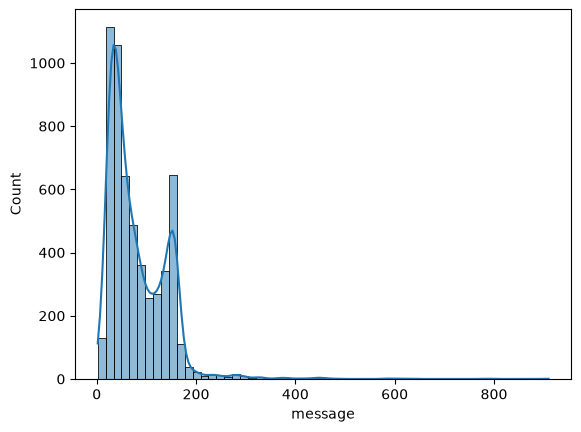

In [53]:
import seaborn as sns

message_length = df["message"].str.len()

sns.histplot(
    df,
    x=message_length,
    binwidth=16,
    kde=True,
)

print(f"Mean length of the message: {int(message_length.mean())}")
print(f"The longest message: {message_length.max()}")
print(f"The shortest message: {message_length.min()}")

print(f"The shortes message is just '{df.loc[df["message"].str.len() == 2].iloc[0]["message"]}'")

### Observation
The shortest message contains two words, while the longest contains 910 words. On average, messages contain approximately 80 words.

## 3.2 Messagen length by label

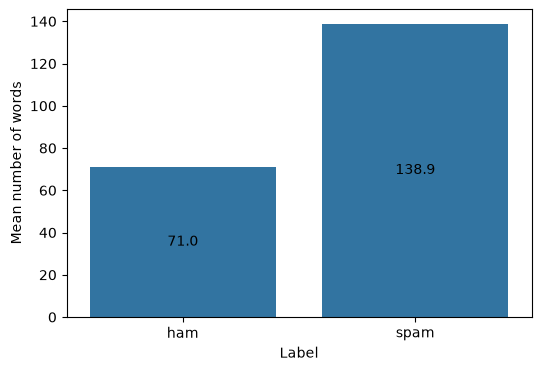

In [153]:
import matplotlib.pyplot as plt

length_of_messages = df.groupby("label")["message"].apply(lambda x: x.str.len().mean())

plt.figure(figsize=(6,4))

ax = sns.barplot(
    x=length_of_messages.index,
    y=length_of_messages.values,

)

ax.bar_label(ax.containers[0], fmt="%.1f", label_type="center")

plt.xlabel("Label")
plt.ylabel("Mean number of words")
plt.show()

### Observation
Spam messages are, on average, almost twice as long as ham messages. This suggests that message length may be a useful feature for distinguishing between the two classes.

## 3.3 Most frequent words by label

In [89]:
import string
import nltk

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\macie\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [122]:
from nltk.corpus import stopwords

def count_num_of_words(label, top_n):
    """
    Count the number of words in given label and 
    return dict object of top_n most frequentyl occurs words
    """
    messages = df[df["label"] == label]["message"].to_dict()
    stop_words = stopwords.words("english")
    num_word = {}

    for message in messages.values():
        for word in str(message).split():
            word = word.lower()
            if word in stop_words or len(word) == 1:
                continue

            word_preprocessed = ""
            for letter in word:
                if letter not in string.punctuation:
                    word_preprocessed += letter
            if word_preprocessed:
                if word_preprocessed not in num_word:
                    num_word[word_preprocessed] = 1
                else:
                    num_word[word_preprocessed] += 1

    sorted_words = {k:v for k, v in sorted(num_word.items(), key=lambda item: item[1], reverse=True)}

    num = 0
    top_n_words = {}
    for k, v in sorted_words.items():
        if num > top_n - 1:
            break
        else:
            top_n_words[k] = v
            num += 1
    return top_n_words

top_ham_words = count_num_of_words("ham", 10)
top_spam_words = count_num_of_words("spam", 10)

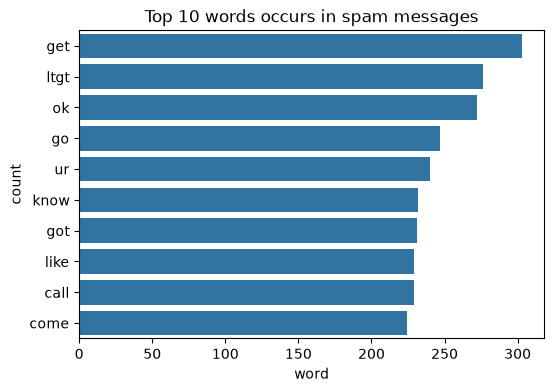

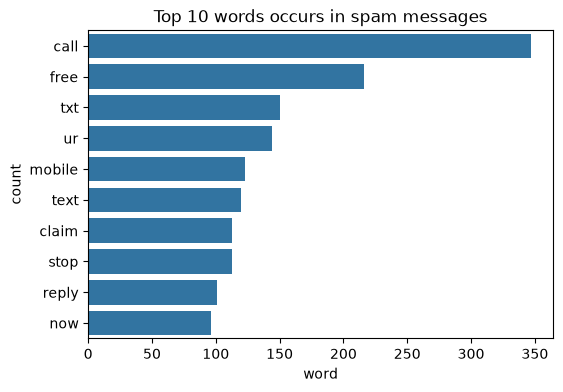

In [ ]:
df_ham_words = pd.DataFrame(
    top_ham_words.items(),
    columns=["count", "word"]
    )

df_spam_words = pd.DataFrame(
    top_spam_words.items(),
    columns=["count", "word"]
)

plt.figure(figsize=(6,4))
sns.barplot(
    df_ham_words,
    y="count",
    x="word",
    legend=False
)
plt.title("Top 10 words occurs in spam messages")
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(
    df_spam_words,
    y="count",
    x="word",
    legend=False
)
plt.title("Top 10 words occurs in spam messages")
plt.show()

### Observation
The two figures show a clear difference in the vocabulary used in spam and ham messages. Spam messages frequently contain call-to-action words such as call, text, claim, reply, and now, which encourage the recipient to take immediate action. They also commonly include words associated with urgency or time-sensitive offers, such as now and stop. 
In contrast, ham messages contain more conversational and everyday language, reflecting normal communication between people, with words such as you, know, like, and just appearing more frequently.